# Six-category radar plot from CSV tables

This notebook reads a `mean ± std` CSV table directly and draws the same no-caption radar style as `six_category_radar_no_caption.py`.

Run order:
1. Set `SPLIT` and `CSV_PATH`.
2. Run data loading.
3. Run ranking.
4. Run plotting.

The data-reading and plotting parts are intentionally separated.


## 1. Configuration


In [39]:
from pathlib import Path

REPO_ROOT = Path('/benchmark-eeg/5.0_version')
TABLE_DIR = REPO_ROOT / 'tables' / 'withstd'
OUT_DIR = REPO_ROOT / 'analysis' / 'six_category_radar'
REFERENCE_CSV = REPO_ROOT / 'experiment_tracking' / 'experiment_reference_with_label.csv'
LABEL_CSV = REPO_ROOT / 'experiment_tracking' / 'experiment_reference_with_label.csv'

# Change these two values when needed.
SPLIT = 'within'  # 'cross' or 'within'
CSV_PATH = '/benchmark-eeg/5.0_version/tables/withstd/within_subject_marking_pretrained_pairs.csv'

# Example for within-subject:
# SPLIT = 'within'
# CSV_PATH = TABLE_DIR / 'benchmark_results_linear_downsample_within_subject_mean_var.csv'

EXCLUDE_BELOW_CHANCE = True
OUT_STEM = f'linear_downsample_{SPLIT}_six_category_from_csv_notebook_v2'

print('SPLIT =', SPLIT)
print('CSV_PATH =', CSV_PATH)
print('OUT_STEM =', OUT_STEM)


SPLIT = within
CSV_PATH = /benchmark-eeg/5.0_version/tables/withstd/within_subject_marking_pretrained_pairs.csv
OUT_STEM = linear_downsample_within_six_category_from_csv_notebook_v2


## 2. Imports and Constants


In [40]:
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

MODEL_ORDER = [
    'brainomni',
    'labram',
    'biot',
    'femba',
    'neurolm',
    'cbramod',
    'neurogpt',
    'reve',
    'eegmamba',
    'bendr',
]

MODEL_LABEL = {
    'brainomni': 'BrainOmni',
    'labram': 'LaBraM',
    'biot': 'BIOT',
    'femba': 'FEMBA',
    'neurolm': 'NeuroLM',
    'cbramod': 'CBraMod',
    'neurogpt': 'NeuroGPT',
    'reve': 'REVE',
    'eegmamba': 'EEGMamba',
    'bendr': 'BENDR',
}

CATEGORY_ORDER = ['Type-I', 'Type-II', 'Type-III', 'Type-IV', 'Type-V', 'Type-VI']
CATEGORY_LABEL = {
    'Type-I': 'Signal\nReliability',
    'Type-II': 'Biometrics\n& Disease',
    'Type-III': 'Consciousness\n& State',
    'Type-IV': 'Cognition\n& Emotion',
    'Type-V': 'Naturalistic\nStimulus Decoding',
    'Type-VI': 'Motor\n& Interaction',
}


## 3. Helpers


In [ ]:
def clean(value) -> str:
    if value is None:
        return ''
    if isinstance(value, float) and np.isnan(value):
        return ''
    return str(value).strip()


def normalize_name(value: str) -> str:
    key = clean(value).lower()
    replacements = {
        '–': '_',
        '—': '_',
        '-': '_',
        ' ': '_',
        '（': '(',
        '）': ')',
        'monitering': 'monitoring',
        'extraversial': 'extraversion',
        'fintuen': 'finetune',
    }
    for src, dst in replacements.items():
        key = key.replace(src, dst)
    key = re.sub(r'\([^)]*\)', '', key)
    key = re.sub(r'_balanced$', '', key)
    key = re.sub(r'_old_badscale$', '', key)
    key = re.sub(r'_wsn$', '', key)
    return re.sub(r'[^a-z0-9]+', '', key)


def parse_mean(value) -> float:
    text = clean(value)
    if not text or text == '--':
        return float('nan')
    match = re.search(r'[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?', text)
    if not match:
        return float('nan')
    return float(match.group(0))


def load_chance_levels(path: Path) -> dict[str, float]:
    label_df = pd.read_csv(path, encoding='utf-8-sig', keep_default_na=False)
    mapping = {}
    for _, row in label_df.iterrows():
        try:
            n = int(row['num_labels'])
            if n > 0:
                mapping[normalize_name(clean(row['dataset']))] = 1.0 / n
        except (ValueError, KeyError):
            pass
    return mapping


## 4. Load Reference Categories

The CSV table provides model scores. The reference tables are only used to map each dataset to one of the six categories and to get chance level.


In [ ]:
# CSV dataset name → reference dataset_key (normalized), for names that differ between files.
NAME_ALIASES = {
    'longitudinaltestretest': 'longitudinaleegreliability',
}


def load_category_reference(reference_path: Path, label_path: Path) -> pd.DataFrame:
    chance_map = load_chance_levels(label_path)

    def load_rows(path: Path) -> pd.DataFrame:
        frame = pd.read_csv(path, encoding='utf-8-sig', keep_default_na=False)
        frame['dataset_display'] = frame['dataset'].map(clean)
        frame['dataset_exp_name'] = frame.get('dataset_exp_name', '').map(clean)
        frame['category'] = frame['category'].map(clean)
        frame = frame[frame['category'].isin(CATEGORY_ORDER)].copy()
        frame['dataset_key'] = frame['dataset_display'].map(normalize_name)
        frame['chance_level'] = frame['dataset_key'].map(chance_map)
        return frame

    ref = load_rows(reference_path)
    label_ref = load_rows(label_path)
    known_keys = set(ref['dataset_key'])
    fallback_rows = label_ref[~label_ref['dataset_key'].isin(known_keys)].copy()
    return pd.concat([ref, fallback_rows], ignore_index=True)


def build_reference_lookup(ref: pd.DataFrame) -> dict:
    lookup = {}
    for _, row in ref.iterrows():
        for col in ('dataset_display', 'dataset_exp_name'):
            key = normalize_name(row.get(col, ''))
            if key and key not in lookup:
                lookup[key] = row
    return lookup


def find_reference_row(dataset_name: str, lookup: dict):
    key = normalize_name(dataset_name)
    key = NAME_ALIASES.get(key, key)
    return lookup.get(key)


reference_df = load_category_reference(REFERENCE_CSV, LABEL_CSV)
PLOT_CATEGORY_ORDER = {
    'cross': ['Type-II', 'Type-III', 'Type-IV', 'Type-V', 'Type-VI'],
    'within': ['Type-I', 'Type-III', 'Type-IV', 'Type-V', 'Type-VI'],
}[SPLIT]

reference_df = load_category_reference(REFERENCE_CSV, LABEL_CSV)
reference_df = reference_df[reference_df['category'].isin(PLOT_CATEGORY_ORDER)].copy()

print(f'Categories used for {SPLIT}: {PLOT_CATEGORY_ORDER}')
print(f'Reference category rows used: {len(reference_df)}')

reference_df.head()


## 5. Read CSV Data

This section reads the CSV table and converts it to a long table with columns like `category`, `dataset`, `model`, and `accuracy`.


In [ ]:
def load_csv_results(csv_path: Path, ref: pd.DataFrame):
    wide = pd.read_csv(csv_path, index_col=0, encoding='utf-8-sig', keep_default_na=False)
    wide.index = wide.index.map(clean)

    # Keep the same policy as the original script: use reve_new as reve when available.
    if 'reve_new' in wide.columns:
        if 'reve' not in wide.columns:
            wide['reve'] = wide['reve_new']
        else:
            reve_new_mean = wide['reve_new'].map(parse_mean)
            has_reve_new = reve_new_mean.notna()
            wide.loc[has_reve_new, 'reve'] = wide.loc[has_reve_new, 'reve_new']

    model_cols = [model for model in MODEL_ORDER if model in wide.columns]
    if not model_cols:
        raise RuntimeError(f'No known model columns found in {csv_path}')

    ref_lookup = build_reference_lookup(ref)
    records = []
    matched_rows = []
    unmatched = []
    n_data_rows = 0

    for dataset_name, row in wide.iterrows():
        if normalize_name(dataset_name) in {'mean', 'std', 'n'}:
            continue
        n_data_rows += 1
        ref_row = find_reference_row(dataset_name, ref_lookup)
        if ref_row is None:
            unmatched.append(dataset_name)
            continue

        matched_rows.append({
            'category': ref_row['category'],
            'dataset_display': ref_row['dataset_display'],
            'dataset_exp_name': ref_row['dataset_exp_name'],
            'csv_dataset': dataset_name,
        })

        for model in model_cols:
            accuracy = parse_mean(row[model])
            if np.isnan(accuracy):
                continue
            records.append({
                'category': ref_row['category'],
                'dataset': ref_row['dataset_display'],
                'dataset_exp_name': ref_row['dataset_exp_name'],
                'csv_dataset': dataset_name,
                'seed': 0,
                'model': model,
                'model_label': MODEL_LABEL[model],
                'accuracy': accuracy,
                'chance_level': ref_row.get('chance_level'),
                'source_csv': str(csv_path),
            })

    if unmatched:
        print(f'[match] {len(unmatched)} CSV datasets were not found in the reference and were skipped:')
        print(', '.join(unmatched))

    long_df = pd.DataFrame(records)
    matched_df = pd.DataFrame(matched_rows).drop_duplicates('csv_dataset')
    return long_df, matched_df, n_data_rows


long_df, matched_df, n_data_rows = load_csv_results(CSV_PATH, reference_df)
print(f'Matched CSV datasets: {matched_df["csv_dataset"].nunique()} / {n_data_rows}')
print(f'Datasets with plotted results: {long_df["dataset"].nunique()}')
print(f'Long result rows: {len(long_df)}')
long_df.head()


In [49]:
matched_df

,category,dataset_display,dataset_exp_name,csv_dataset
0,Type-I,EEGDenoiseNet,EEGDenoiseNet,EEGDenoiseNet
1,Type-III,Awakening,Awakening,Awakening
2,Type-III,HMC,HMC,HMC
3,Type-III,HBN_EEG,HBN_EEG,HBN EEG
4,Type-III,PEARL_Neuro,PEARL_Neuro_wsn,PEARL-Neuro
5,Type-III,RestCog,RestCog_wsn,RestCog
6,Type-IV,SEED,SEED,SEED
7,Type-IV,SEED_VII,SEED_VII,SEED-VII
8,Type-IV,SEED_FRA,SEED_FRA_wsn,SEED-FRA
9,Type-IV,CIRE,CIRE_wsn,CIRE


## 6. Compute Category Ranks


In [45]:
def build_category_rank(long_df: pd.DataFrame, exclude_below_chance: bool = True):
    mean_df = (
        long_df.groupby(['category', 'dataset', 'model'], as_index=False)
        .agg(
            mean_accuracy=('accuracy', 'mean'),
            n_seed=('seed', 'nunique'),
            chance_level=('chance_level', 'first'),
        )
    )

    if exclude_below_chance:
        below_chance = (
            mean_df['chance_level'].notna()
            & (mean_df['mean_accuracy'] < mean_df['chance_level'])
        )
        n_below = below_chance.sum()
        if n_below:
            print(
                f'[below-chance] excluding {n_below} (dataset, model) pairs from ranking '
                f'(mean_accuracy < chance_level)'
            )
            mean_df.loc[below_chance, 'mean_accuracy'] = float('nan')
    else:
        print('[below-chance] exclusion disabled; all results included in ranking')

    acc_pivot = mean_df.pivot(index='dataset', columns='model', values='mean_accuracy')
    category_by_dataset = mean_df.drop_duplicates('dataset').set_index('dataset')['category']

    # Higher accuracy gets a better rank. Missing or below-chance results are pushed to bottom.
    rank_df = acc_pivot.rank(axis=1, ascending=False, method='average', na_option='bottom')
    rank_df['category'] = category_by_dataset
    cat_rank = rank_df.groupby('category').mean(numeric_only=True).reindex(PLOT_CATEGORY_ORDER)
    cat_rank = cat_rank.dropna(how='all')

    model_order = cat_rank.mean(axis=0, skipna=True).sort_values().index.tolist()
    cat_rank = cat_rank[model_order]
    return mean_df, rank_df, cat_rank


mean_df, rank_df, cat_rank = build_category_rank(long_df, exclude_below_chance=EXCLUDE_BELOW_CHANCE)
cat_rank_labeled = cat_rank.rename(columns=MODEL_LABEL)
cat_rank_labeled


[below-chance] excluding 30 (dataset, model) pairs from ranking (mean_accuracy < chance_level)


model,LaBraM,CBraMod,BrainOmni,NeuroLM,BIOT,FEMBA,NeuroGPT,REVE,EEGMamba,BENDR
category,,,,,,,,,,
Type-I,2.000000,1.000000,4.0,8.5,8.500000,8.500000,3.0,5.000000,8.500000,6.000000
Type-III,2.600000,6.000000,8.4,3.6,2.400000,2.800000,5.8,7.800000,6.400000,9.200000
Type-IV,6.400000,4.800000,3.0,5.0,5.000000,3.800000,5.4,7.600000,5.400000,8.600000
Type-V,3.833333,5.666667,7.0,3.5,2.333333,5.833333,7.0,5.833333,6.833333,7.166667
Type-VI,8.300000,5.800000,1.4,3.4,5.800000,4.400000,6.4,6.700000,6.900000,5.900000


## 7. Plot Radar

This cell only draws and saves the radar figure. It does not read or transform data.


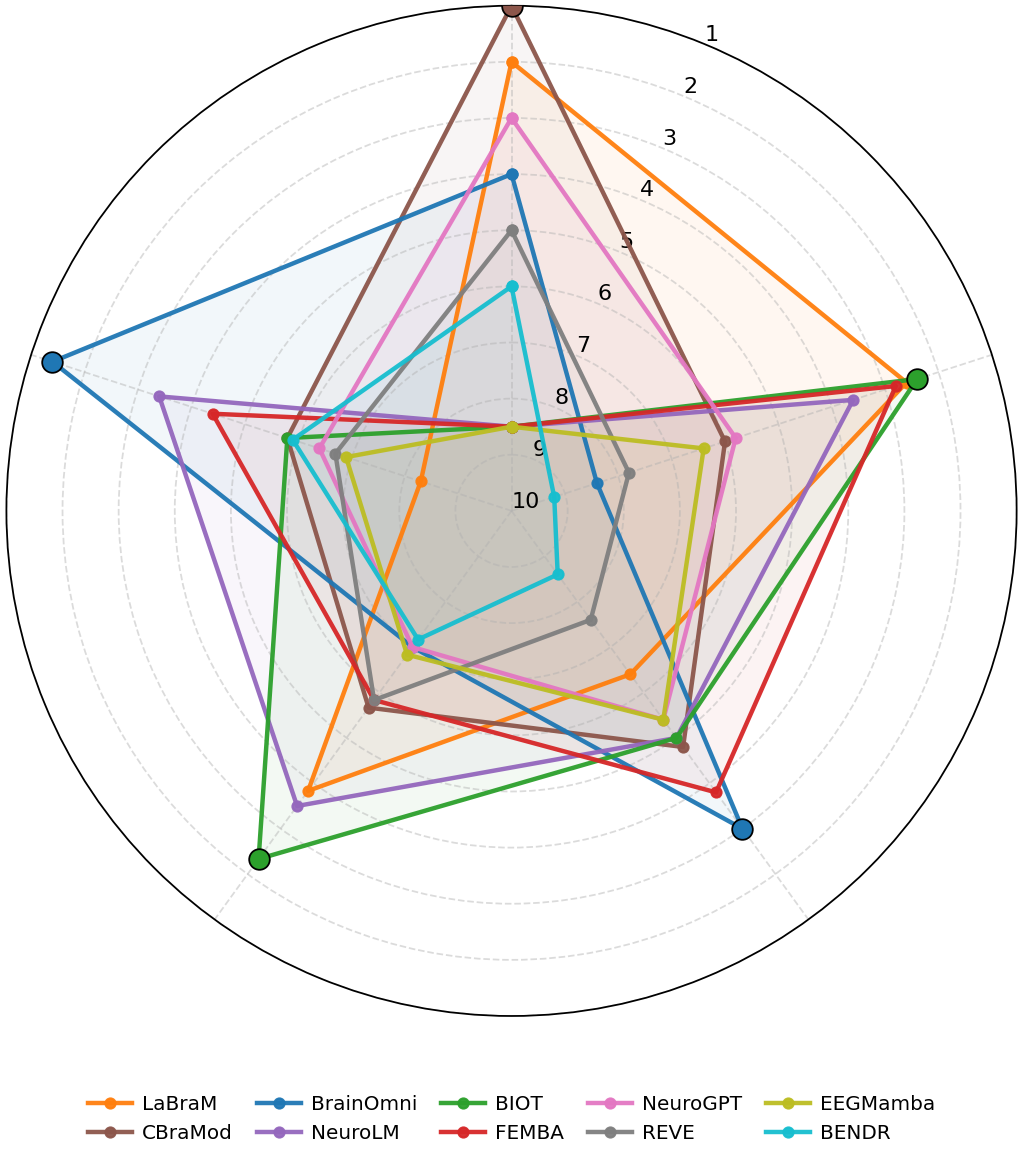

/benchmark-eeg/5.0_version/analysis/six_category_radar/linear_downsample_within_six_category_from_csv_notebook_v2_radar.png
/benchmark-eeg/5.0_version/analysis/six_category_radar/linear_downsample_within_six_category_from_csv_notebook_v2_radar.pdf


In [46]:
def plot_radar(cat_rank: pd.DataFrame, out_dir: Path, stem: str):
    mpl.rcParams.update({
        'figure.dpi': 160,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.04,
        'font.family': 'sans-serif',
        'font.size': 10,
        'axes.titlesize': 13,
        'legend.fontsize': 9,
    })

    n_categories = len(cat_rank.index)
    angles = np.linspace(0, 2 * np.pi, n_categories, endpoint=False).tolist()
    angles += angles[:1]

    inner = 1
    outer = 10.0

    fig = plt.figure(figsize=(8.6, 8.2))
    ax = plt.subplot(111, polar=True)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([])
    ax.tick_params(axis='x', length=0)
    ax.set_ylim(outer, inner)
    # grid_r = np.arange(inner, outer + 0.01, 1.0)
    # ax.set_yticks(grid_r)
    # ax.set_yticklabels([f'{int(r)}' for r in grid_r], fontsize=8)
    ax.grid(True, linestyle='--', linewidth=0.8, alpha=0.45)

    palette = plt.get_cmap('tab10').colors
    model_color = {m: palette[i % len(palette)] for i, m in enumerate(MODEL_ORDER)}
    best_model_per_cat = cat_rank.idxmin(axis=1).to_dict()

    for model in cat_rank.columns.tolist():
        vals = cat_rank[model].astype(float).tolist()
        vals_closed = vals + vals[:1]
        color = model_color.get(model, palette[0])
        ax.plot(
            angles,
            vals_closed,
            linewidth=2.0,
            marker='o',
            markersize=4.5,
            label=MODEL_LABEL.get(model, model),
            color=color,
            alpha=0.95,
        )
        ax.fill(angles, vals_closed, color=color, alpha=0.055)

        for j, cat in enumerate(cat_rank.index):
            if best_model_per_cat.get(cat) == model:
                ax.scatter(
                    angles[j],
                    vals[j],
                    s=86,
                    color=color,
                    edgecolors='black',
                    linewidths=0.8,
                    zorder=5,
                )

    # Category labels around the radar
    # label_r = inner - 0.5
    # for angle, cat in zip(angles[:-1], cat_rank.index):
    #     ax.text(
    #         angle,
    #         label_r,
    #         CATEGORY_LABEL.get(cat, cat),
    #         ha='center',
    #         va='center',
    #         fontsize=10,
    #         fontweight='medium',
    #         clip_on=False
    #     )

    # Model legend
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.06),
        ncol=5,
        frameon=False,
        fontsize=9,
        handlelength=2.2,
        columnspacing=1.2,
        handletextpad=0.5,
    )


    out_dir.mkdir(parents=True, exist_ok=True)
    png_path = out_dir / f'{stem}_radar.png'
    pdf_path = out_dir / f'{stem}_radar.pdf'
    fig.savefig(png_path)
    fig.savefig(pdf_path)
    plt.show()
    plt.close(fig)
    return png_path, pdf_path



png_path, pdf_path = plot_radar(cat_rank, OUT_DIR, OUT_STEM)
print(png_path)
print(pdf_path)


## 8. Save Intermediate Tables


In [47]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

long_path = OUT_DIR / f'{OUT_STEM}_long.csv'
mean_path = OUT_DIR / f'{OUT_STEM}_dataset_model_mean.csv'
rank_path = OUT_DIR / f'{OUT_STEM}_dataset_model_rank.csv'
avg_rank_path = OUT_DIR / f'{OUT_STEM}_avg_rank.csv'
matched_path = OUT_DIR / f'{OUT_STEM}_matched_datasets.csv'

long_df.to_csv(long_path, index=False)
mean_df.to_csv(mean_path, index=False)
rank_df.to_csv(rank_path)
cat_rank_labeled.to_csv(avg_rank_path)
matched_df.to_csv(matched_path, index=False)

print(long_path)
print(mean_path)
print(rank_path)
print(avg_rank_path)
print(matched_path)


/benchmark-eeg/5.0_version/analysis/six_category_radar/linear_downsample_within_six_category_from_csv_notebook_v2_long.csv
/benchmark-eeg/5.0_version/analysis/six_category_radar/linear_downsample_within_six_category_from_csv_notebook_v2_dataset_model_mean.csv
/benchmark-eeg/5.0_version/analysis/six_category_radar/linear_downsample_within_six_category_from_csv_notebook_v2_dataset_model_rank.csv
/benchmark-eeg/5.0_version/analysis/six_category_radar/linear_downsample_within_six_category_from_csv_notebook_v2_avg_rank.csv
/benchmark-eeg/5.0_version/analysis/six_category_radar/linear_downsample_within_six_category_from_csv_notebook_v2_matched_datasets.csv


## 9. Display Saved PNG


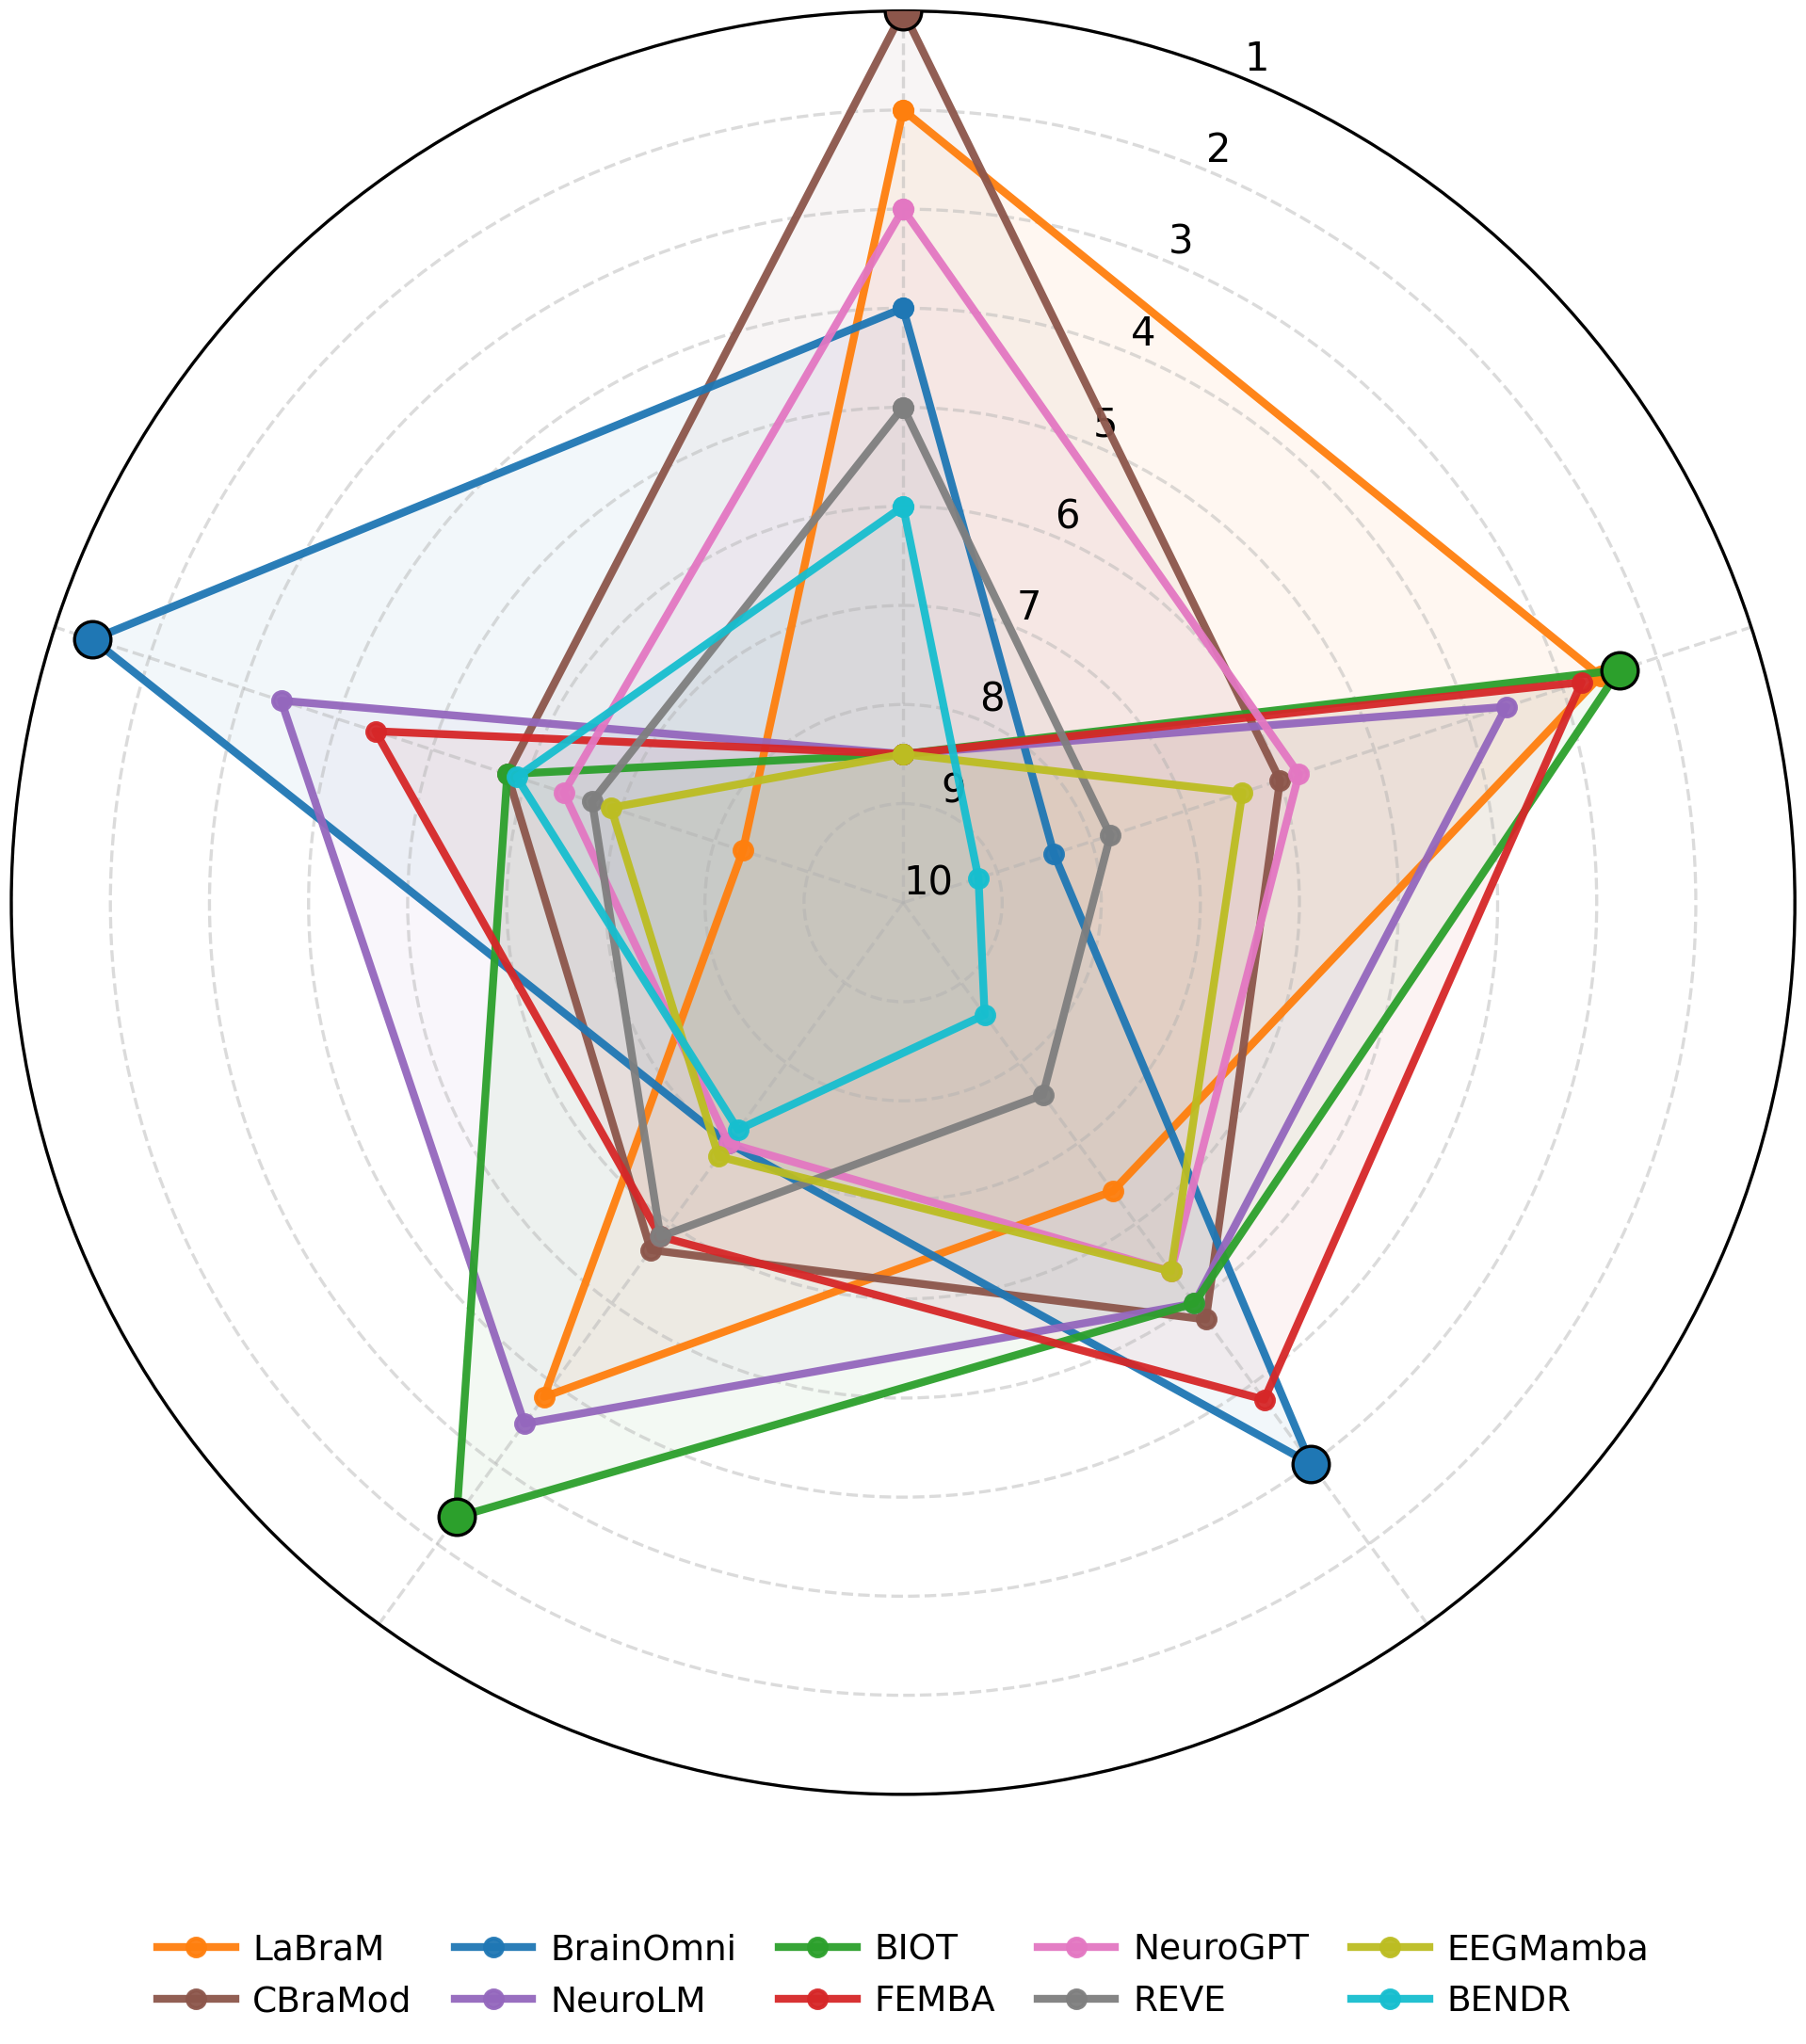

In [48]:
display(Image(filename=str(png_path)))
